# **Caso People Analytics IV: Performance**

En este caso vamos a trabajar con un dataset simulado de una empresa tecnológica de tamaño medio.

El objetivo es analizar qué factores pueden estar relacionados con un bajo desempeño laboral y, más adelante, construir un modelo que nos permita anticiparlo.

El dataset incluye variables como:

a) Edad.
b) Antigüedad.
c) Departamento.
d) Nivel salarial.
e) Engagement.
f) Formación recibida.
g) Absentismo.


Vamos a trabajar el caso paso a paso:

1) Exploración y calidad del dato

2) Limpieza y tratamiento

3) Análisis exploratorio (EDA)

4) Modelización

5) Interpretación y conclusiones estratégicas

In [1]:
# Importamos las librerías necesarias

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargamos el dataset
employees = pd.read_csv("https://raw.githubusercontent.com/Pablolg87/people-analytics-performance-prediction/refs/heads/main/performance_people_analytics.csv")

# Vemos su tamaño
print("Shape del dataset:", employees.shape)

# Le damos un "primer vistazo"
employees.head()

Shape del dataset: (355, 12)


,employee_id,age,tenure_years,department,seniority_level,salary_band_k,engagement_score,training_hours_last_year,absenteeism_rate,project_load_index,previous_performance_rating,low_performance
0,1000,51,3.0,Marketing,Lead,61,NaN,NaN,0.033,0.91,3,1
1,1001,37,2.8,Finance,Mid,85,1.92,33.0,0.189,0.81,3,1
2,1002,30,4.1,Sales,Mid,67,1.21,51.0,0.170,1.18,5,1
3,1003,43,8.5,Finance,Junior,63,3.56,51.0,0.134,1.11,3,0
4,1004,41,10.9,Finance,Senior,80,1.90,28.0,0.092,0.86,3,1


In [3]:
# Revisamos tipos de datos

employees.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   employee_id                  355 non-null    int64  
 1   age                          355 non-null    int64  
 2   tenure_years                 355 non-null    float64
 3   department                   355 non-null    object 
 4   seniority_level              355 non-null    object 
 5   salary_band_k                355 non-null    int64  
 6   engagement_score             337 non-null    float64
 7   training_hours_last_year     336 non-null    float64
 8   absenteeism_rate             336 non-null    float64
 9   project_load_index           355 non-null    float64
 10  previous_performance_rating  355 non-null    int64  
 11  low_performance              355 non-null    int64  
dtypes: float64(5), int64(5), object(2)
memory usage: 33.4+ KB


# **Descripción de las Variables del Dataset**

A continuación se describen todas las variables incluidas en el dataset utilizado para el análisis de bajo desempeño:

**Identificación**

- employee_id: Identificador único del empleado. No tiene valor analítico directo, se usa para trazabilidad.

**Variables Demográficas y Organizativas**

- age: Edad del empleado (años).

- tenure_years: Antigüedad en la empresa (años).

- department: Área organizativa a la que pertenece (Engineering, Product, Sales, etc.).

- seniority_level: Nivel jerárquico (Junior, Mid, Senior, Lead).

- salary_band_k: Banda salarial aproximada en miles de euros anuales.

**Variables de Comportamiento y Gestión**

- engagement_score: Índice de compromiso del empleado (escala 1–5).

- training_hours_last_year: Número de horas de formación recibidas en el último año.

- absenteeism_rate: Tasa de absentismo (proporción entre 0 y 0.2).

- project_load_index: Índice de carga de trabajo relativo (0.5 = baja carga, 1 = estándar, 1.5 = alta carga).

- previous_performance_rating: Evaluación de desempeño anterior (escala 1–5).

**Variable Objetivo (Target)**

- low_performance: Variable binaria que indica bajo desempeño actual.

0 = desempeño adecuado

1 = bajo desempeño

**Limpieza de datos preliminar**

In [4]:
# Revisamos duplicados y los eliminamos

print("Filas antes de eliminar duplicados:", employees.shape[0])

employees = employees.drop_duplicates()

print("Filas después de eliminar duplicados:", employees.shape[0])

Filas antes de eliminar duplicados: 355
Filas después de eliminar duplicados: 350


In [5]:
# Valores nulos, si los hay lo rellenamos con la media

print("Nulos por columna:")
display(employees.isnull().sum())

print("\nPorcentaje de nulos:")
display((employees.isnull().mean() * 100).round(2))

Nulos por columna:


,0
employee_id,0
age,0
tenure_years,0
department,0
seniority_level,0
salary_band_k,0
engagement_score,18
training_hours_last_year,18
absenteeism_rate,18
project_load_index,0



Porcentaje de nulos:


,0
employee_id,0.00
age,0.00
tenure_years,0.00
department,0.00
seniority_level,0.00
salary_band_k,0.00
engagement_score,5.14
training_hours_last_year,5.14
absenteeism_rate,5.14
project_load_index,0.00


In [6]:
# Imputamos en los valores nulos la mediana

cols_with_nulls = [
    "engagement_score",
    "training_hours_last_year",
    "absenteeism_rate"
]

# Imputación por mediana
for col in cols_with_nulls:
    employees[col] = employees[col].fillna(employees[col].median())

# Verificamos que ya no quedan nulos
print("Nulos después de imputar:")
display(employees[cols_with_nulls].isnull().sum())

Nulos después de imputar:


,0
engagement_score,0
training_hours_last_year,0
absenteeism_rate,0


**EDA**

In [7]:
# Estadística preliminar

employees.describe()

,employee_id,age,tenure_years,salary_band_k,engagement_score,training_hours_last_year,absenteeism_rate,project_load_index,previous_performance_rating,low_performance
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,1174.500000,41.868571,7.652286,56.911429,2.951314,37.428571,0.100006,0.996629,3.482857,0.611429
std,101.180532,11.031338,4.313965,19.147613,1.070081,22.188933,0.055650,0.290942,1.031589,0.488123
min,1000.000000,23.000000,0.700000,25.000000,1.000000,0.000000,0.000000,0.500000,1.000000,0.000000
25%,1087.250000,31.000000,3.825000,39.500000,2.020000,19.000000,0.056000,0.772500,3.000000,0.000000
50%,1174.500000,43.500000,7.600000,57.000000,3.000000,36.000000,0.102500,0.990000,4.000000,1.000000
75%,1261.750000,51.000000,11.400000,73.000000,3.715000,56.750000,0.144750,1.260000,4.000000,1.000000
max,1349.000000,59.000000,15.000000,89.000000,4.980000,79.000000,0.199000,1.500000,5.000000,1.000000


Distribución absoluta:


,count
low_performance,
1,214
0,136



Distribución porcentual:


,proportion
low_performance,
1,61.14
0,38.86


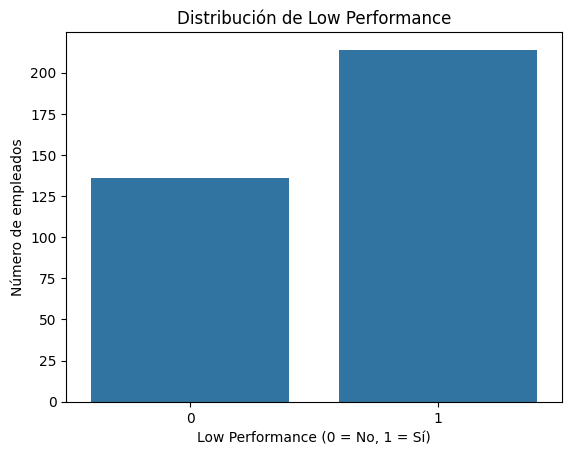

In [8]:
# Revisamos distribución de lo que queremos evitar
# (en este caso, low performance)

print("Distribución absoluta:")
display(employees["low_performance"].value_counts())

print("\nDistribución porcentual:")
display((employees["low_performance"].value_counts(normalize=True) * 100).round(2))


# Visualización
plt.figure()
sns.countplot(data=employees, x="low_performance")

plt.title("Distribución de Low Performance")
plt.xlabel("Low Performance (0 = No, 1 = Sí)")
plt.ylabel("Número de empleados")

plt.show()

Vemos low performance por departamento:

In [9]:
# Porcentaje de low_performance por departamento
dept_performance = (
    employees
    .groupby("department")["low_performance"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

dept_performance.round(2)

,low_performance
department,
Product,70.83
HR,64.29
Marketing,62.96
Sales,60.94
Finance,57.35
Engineering,53.33


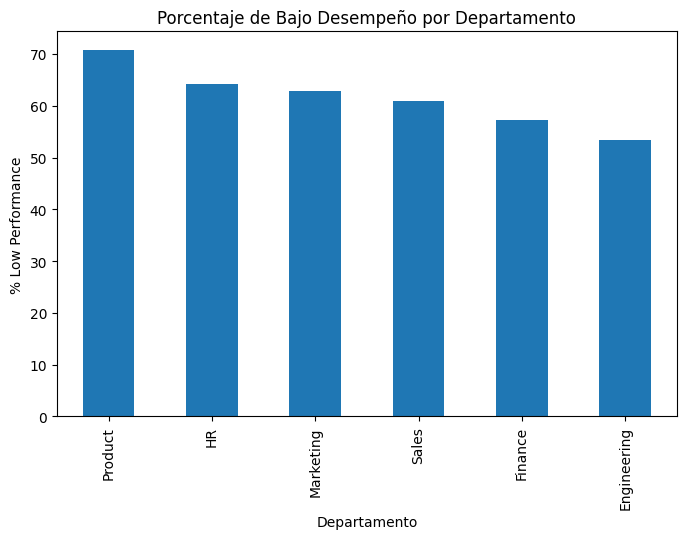

In [10]:
plt.figure(figsize=(8,5))
dept_performance.plot(kind="bar")
plt.title("Porcentaje de Bajo Desempeño por Departamento")
plt.ylabel("% Low Performance")
plt.xlabel("Departamento")
plt.show()

Lo mismo, pero por "seniority":

In [11]:
seniority_performance = (
    employees
    .groupby("seniority_level")["low_performance"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

seniority_performance.round(2)

,low_performance
seniority_level,
Mid,64.21
Junior,62.50
Lead,60.27
Senior,56.98


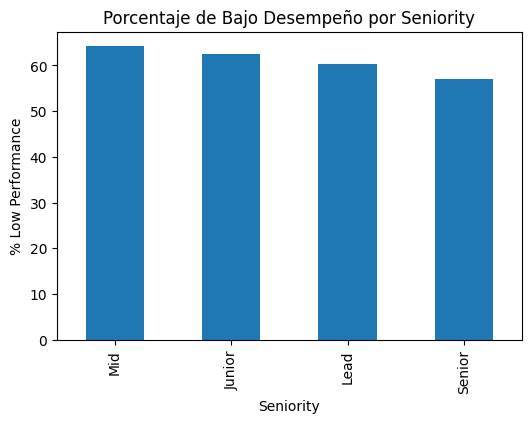

In [12]:
plt.figure(figsize=(6,4))
seniority_performance.plot(kind="bar")
plt.title("Porcentaje de Bajo Desempeño por Seniority")
plt.ylabel("% Low Performance")
plt.xlabel("Seniority")
plt.show()

Se observan diferencias moderadas en el porcentaje de bajo desempeño según departamento y nivel de seniority.

- El área de Product muestra el porcentaje más alto.
- Engineering presenta uno de los más bajos.

En cuanto a niveles:

- Los perfiles Junior y Mid concentran algo más de riesgo que los perfiles Senior.

Sin embargo, las diferencias no son extremas ni indican un problema estructural claro.

Veamos que variables influyen realmente en un "low performance"

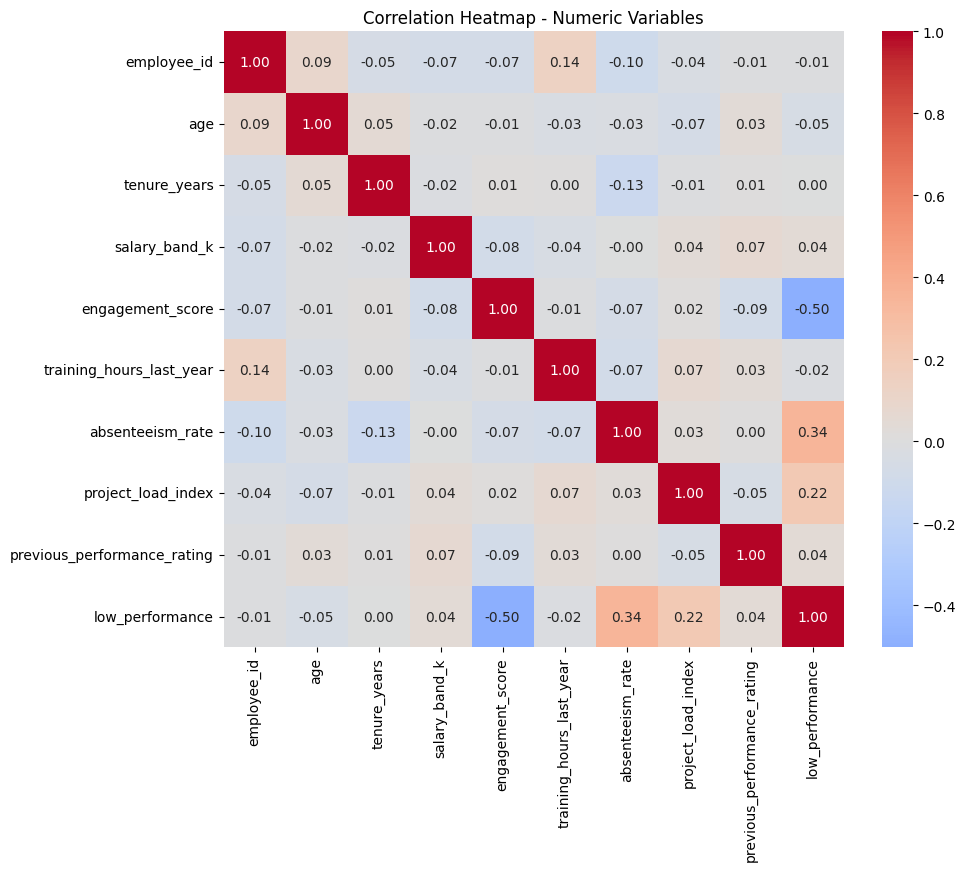

In [13]:
# Matriz de correlación

# Seleccionamos solo variables numéricas
numeric_cols = employees.select_dtypes(include=["int64", "float64"])

# Matriz de correlación
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap - Numeric Variables")
plt.show()

# **Análisis de Variables Clave frente al Bajo Desempeño**

Tras analizar la matriz de correlaciones, hemos identificado tres variables con mayor relación con low_performance:

- Engagement score

- Tasa de absentismo

- Índice de carga de trabajo

En este paso vamos a visualizar cómo se comportan estas variables en función del nivel de desempeño (0 = desempeño adecuado, 1 = bajo desempeño).

El objetivo es comprobar si existen diferencias claras entre ambos grupos y si estas variables muestran capacidad real de separación. Esto nos permitirá validar de forma visual los hallazgos de la matriz de correlaciones y reforzar la interpretación estratégica del análisis.

Si observamos diferencias consistentes entre grupos, estas variables podrán considerarse drivers relevantes del bajo desempeño y candidatas clave para el modelo predictivo posterior.

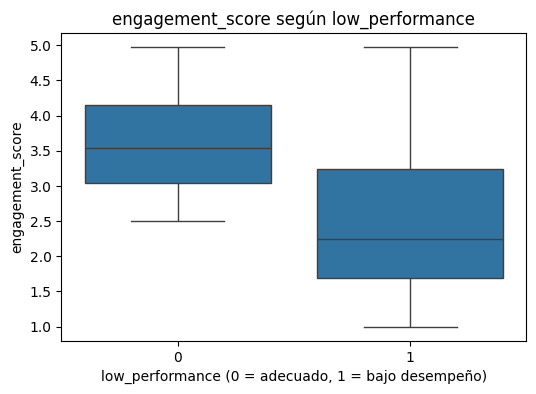

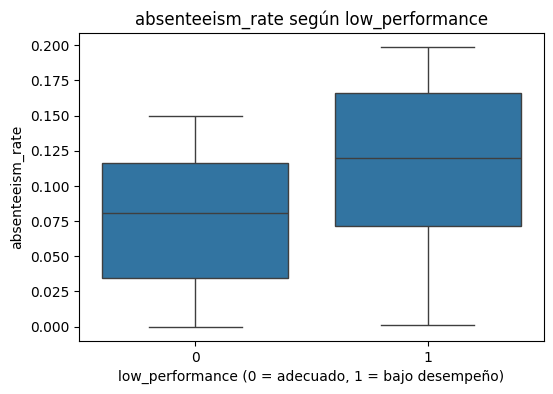

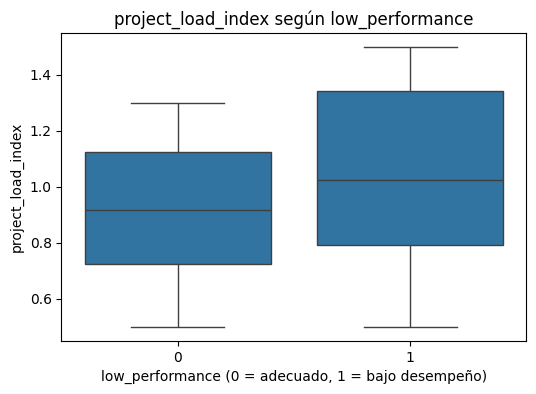

In [14]:
# Seleccionamos las variables que queremos comparar
vars_to_compare = ["engagement_score", "absenteeism_rate", "project_load_index"]

# Visualización (boxplot por variable)
for var in vars_to_compare:
    plt.figure(figsize=(6, 4))  # tamaño del gráfico

    sns.boxplot(data=employees, x="low_performance", y=var)

    # Títulos y ejes
    plt.title(f"{var} según low_performance")
    plt.xlabel("low_performance (0 = adecuado, 1 = bajo desempeño)")
    plt.ylabel(var)

    plt.show()



El **engagement** es la variable que más diferencia a los empleados con bajo desempeño: *cuanto menor es el compromiso, mayor es la probabilidad de bajo rendimiento.*

El **absentismo** también muestra una relación clara, aunque menos intensa: *mayores tasas se asocian con peor desempeño.*

La **carga de trabajo** presenta una diferencia más ligera, por lo que podría influir, *pero no parece ser el factor principal.*

En resumen, *el compromiso del empleado es el elemento más determinante* dentro de este análisis exploratorio.

In [15]:
# Revisión de mediana para ver outliers (outliers)
median_by_group = employees.groupby("low_performance")[vars_to_compare].median()
median_by_group

,engagement_score,absenteeism_rate,project_load_index
low_performance,,,
0,3.545,0.0805,0.915
1,2.250,0.1200,1.025


Los **empleados con buen desempeño tienen, en promedio, mayor engagement (3.55 vs 2.25).**

Esta es la diferencia más clara del análisis.

También **presentan menor absentismo (0.08 vs 0.12) y una ligeramente menor carga de trabajo (0.91 vs 1.02).**

En conjunto, *los datos muestran que el bajo desempeño está especialmente asociado con menor compromiso y, en menor medida, con mayor absentismo y mayor carga laboral.*

# **Preparación para crear el modelo**

Ahora vamos a dar el siguiente paso: construir un modelo que nos ayude a predecir el bajo desempeño.

Antes de entrenarlo, necesitamos organizar los datos:

- Separar la variable que queremos predecir (low_performance) del resto.

- Quitar el identificador del empleado, ya que solo sirve para identificar, no para predecir.

- Convertir las variables de texto (como departamento o nivel) en formato numérico, porque el modelo solo entiende números.

Dividir los datos en dos partes:

a) *Una parte para entrenar el modelo.*

b) *Otra parte para comprobar si funciona bien con datos nuevos.*

En resumen, vamos a preparar el dataset para que el modelo pueda aprender de forma correcta y podamos evaluar su rendimiento de manera fiable.

In [16]:
# Separar variable objetivo
y = employees["low_performance"]

# Variables predictoras (eliminamos target e identificador)
X = employees.drop(columns=["low_performance", "employee_id"])

# Convertir variables categóricas en numéricas
X = pd.get_dummies(X, drop_first=True)

# Dividir en datos de entrenamiento y prueba (70% / 30%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (245, 16)
Test: (105, 16)


In [17]:
# Entrenamiento de modelos

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1️⃣ Regresión Logística
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# 2️⃣ Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# 3️⃣ XGBoost
xgb_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Comparamos los modelos:

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Diccionario para guardar resultados
results = {}

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():

    # Predicciones
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Métricas
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    }

# Convertimos a DataFrame para verlo mejor
results_df = pd.DataFrame(results).T
results_df.round(3)

,Accuracy,Precision,Recall,F1-score,AUC
Logistic Regression,0.752,0.733,0.902,0.809,0.865
Random Forest,0.962,0.938,1.000,0.968,0.997
XGBoost,0.943,0.910,1.000,0.953,0.985


**Resumen de resultados**

*Random Forest y XGBoost obtienen resultados casi perfectos en este análisis.*

*En un entorno real de RRHH, este nivel de precisión sería poco habitual*, ya que el desempeño laboral depende de muchos factores y siempre existe cierto nivel de incertidumbre.

En este caso, el alto rendimiento se debe a que el dataset está construido con relaciones muy claras entre algunas variables y el bajo desempeño.

Por ello, **utilizaremos la Regresión Logística como modelo principal**, ya que *ofrece un buen equilibrio entre rendimiento y facilidad de interpretación*, algo fundamental en contextos de negocio y toma de decisiones en RRHH.

Ahora **vamos a analizar qué variables tienen mayor peso en la predicción del bajo desempeño.**

En la Regresión Logística, cada variable tiene un coeficiente que indica:

1) Si aumenta o reduce la probabilidad de bajo desempeño.

2) Qué tan fuerte es su impacto en el modelo.

Ordenaremos las variables según la magnitud de su efecto para identificar cuáles son más relevantes en la predicción.

In [19]:
# Extraemos coeficientes del modelo
coefficients = pd.DataFrame({
    "Variable": X_train.columns,
    "Coefficient": log_model.coef_[0]
})

# Ordenamos por impacto absoluto
coefficients["Abs_Coefficient"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values(by="Abs_Coefficient", ascending=False)

coefficients.head(10)

,Variable,Coefficient,Abs_Coefficient
6,project_load_index,1.791319,1.791319
5,absenteeism_rate,1.662241,1.662241
3,engagement_score,-1.187187,1.187187
11,department_Product,0.562192,0.562192
9,department_HR,0.359644,0.359644
14,seniority_level_Mid,0.301550,0.301550
13,seniority_level_Lead,0.286889,0.286889
8,department_Finance,-0.247010,0.247010
12,department_Sales,-0.165918,0.165918
15,seniority_level_Senior,-0.132034,0.132034


Ahora vamos a visualizar la matriz de confusión para entender cómo se comporta el modelo en la práctica.

La matriz de confusión nos muestra:

- Cuántos casos de bajo desempeño detecta correctamente.
- Cuántos casos clasifica mal.
- Dónde comete errores (falsos positivos y falsos negativos).

Esto nos ayuda a evaluar el impacto real del modelo en la toma de decisiones.

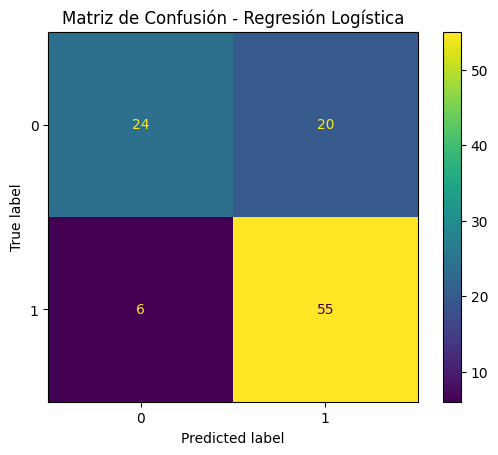

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predicciones
y_pred = log_model.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

**Interpretación en términos de RRHH**

El modelo:

- Detecta muy bien los casos reales de bajo desempeño (solo se le escapan 6).

- Pero tiende a ser algo conservador y marca 20 casos que en realidad no eran problemáticos.

En un entorno real:

- Los falsos negativos son más críticos (no detectar un caso real).

- Los falsos positivos pueden gestionarse con revisión adicional (entrevista, seguimiento, etc.).

Dado que el recall era alto (≈0.90), el modelo prioriza detectar riesgo, lo cual puede ser razonable si el objetivo es prevención.

# **Conclusión Final:**

Hemos construido un modelo para intentar predecir qué empleados pueden tener bajo desempeño.

Los datos muestran que los factores más relacionados con ese riesgo son:

- Bajo engagement (compromiso)

- Mayor absentismo

- Mayor carga de trabajo

El modelo funciona bastante bien y detecta la mayoría de los casos de bajo desempeño.

Aun así, *no debe usarse para tomar decisiones automáticas, sino como una herramienta de apoyo para RRHH.*

En resumen, **este caso demuestra que con datos internos es posible anticipar riesgos y actuar antes de que el problema sea mayor.**